## Malaria

*Abstract*: Causing over 600k deaths and 200 million cases, malaria is a major global health problem. Improving the identification of cases and efficiency of treatment is one way to help tackle this important issue. This dataset contains images of tissue samples labeled as positive or negative for malaria. Modelers will try to create an algorithm that can correctly identify cases of malaria in order to save the limited time of physicians and epidemiologists. Skills from this project will transfer to any image recognition or classification problem, but particularly those in the health care fields.

- Algorithms: Classification CNN

- Difficulty: Flexible! This dataset can utilize off-the-shelf algorithms from class, but has plenty of depth to warrant customization. The bar for accuracy is higher in health care because we are looking after people’s lives!

## Captone Project Link

Links to Capstone Project slides: [here](https://docs.google.com/presentation/d/1iEMLMUSAA-lEe4EzC0sCbiu405Bow7-4zGIj3SKN-1c/edit#slide=id.g107242abc6f_0_12)

## Motivation

Image classification using deep learning has become very popular, and seems to be one of the best methods. Images with more features (and higher resolution) require more sophisticated networks that are able to consider the translation invariance of features, and other important aspects of image classification. Image analysis is a promising application area for AI in medicine. This project will build skills to understand this application area and the challenges that it presents!


## Load Data

The following code use the *tfds* library to load in "malaria" data sets. This is a big image data set with over 27,000 images. The images are colored which means each image has RGB, i.e. 3 channels. Each image is sized 224 by 224.

In [ ]:
# make sure tensorflow_datasets package is at newest possible version
# to ensure that dataset can be loaded properly.
# runtime will need to be restarted after this package is upgraded.
# press the "RESTART RUNTIME" button that appears,
# and DO NOT RUN THIS CELL after the runtime has restarted.
!pip install --upgrade tensorflow_datasets

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [ ]:
# verify that the tensorflow_datasets package has been updated
print(tfds.__version__)
# version 4.6.0 has been verified to work for loading the datasets

4.9.9


In [ ]:
ds_train, train_info = tfds.load('malaria', split='train', with_info=True, as_supervised=True)

In [ ]:
train_info

tfds.core.DatasetInfo(
    name='malaria',
    full_name='malaria/1.0.0',
    description="""
    The Malaria dataset contains a total of 27,558 cell images with equal instances
    of parasitized and uninfected cells from the thin blood smear slide images of
    segmented cells.
    """,
    homepage='https://lhncbc.nlm.nih.gov/publication/pub9932',
    data_dir='/root/tensorflow_datasets/malaria/1.0.0',
    file_format=tfrecord,
    download_size=337.08 MiB,
    dataset_size=317.62 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=27558, num_shards=4>,
    },
    citation="""@article{rajaraman2018pre,
      title={Pre-trained convolutional neural networks as feature extractors toward
      improved malaria parasit

In [ ]:
# function to standardize the image size to what the model expects
def resize_image(image_tensor: tf.Tensor, label_tensor: tf.Tensor):
  im = image.array_to_img(image_tensor.numpy())
  im = im.resize((128, 128))
  im = image.img_to_array(im)
  image_tensor = tf.convert_to_tensor(im, dtype=tf.uint8)
  return image_tensor, label_tensor

In [ ]:
seed = 51
tf.random.set_seed(seed)
ds_train = ds_train.map(lambda x,y: tf.py_function(func=resize_image, inp=[x,y], Tout=(tf.uint8, tf.int64)))
ds_train.shuffle(buffer_size=1024, seed=seed)

<_ShuffleDataset element_spec=(TensorSpec(shape=<unknown>, dtype=tf.uint8, name=None), TensorSpec(shape=<unknown>, dtype=tf.int64, name=None))>

In [ ]:
# this code runs for a while
# go get a cup of coffee!
images = []
labels = []
for image_0, label in ds_train:
  images.append(image_0.numpy())
  labels.append(label.numpy())
  if len(images) > 10000:
    break

## Define Research Question

## EDA

Examples:

- You can count the number of classes in this data.
- You examine the images according to class labels.
- You can plot the averages of pixel-level values across all images in a particular class. In addition, you can also span the visualization for all classes.

You can refer to more resources here in this [code](https://colab.research.google.com/drive/1KkG1V7RsnKjCRd0zx0h434nqiXwOf-fG?authuser=1).

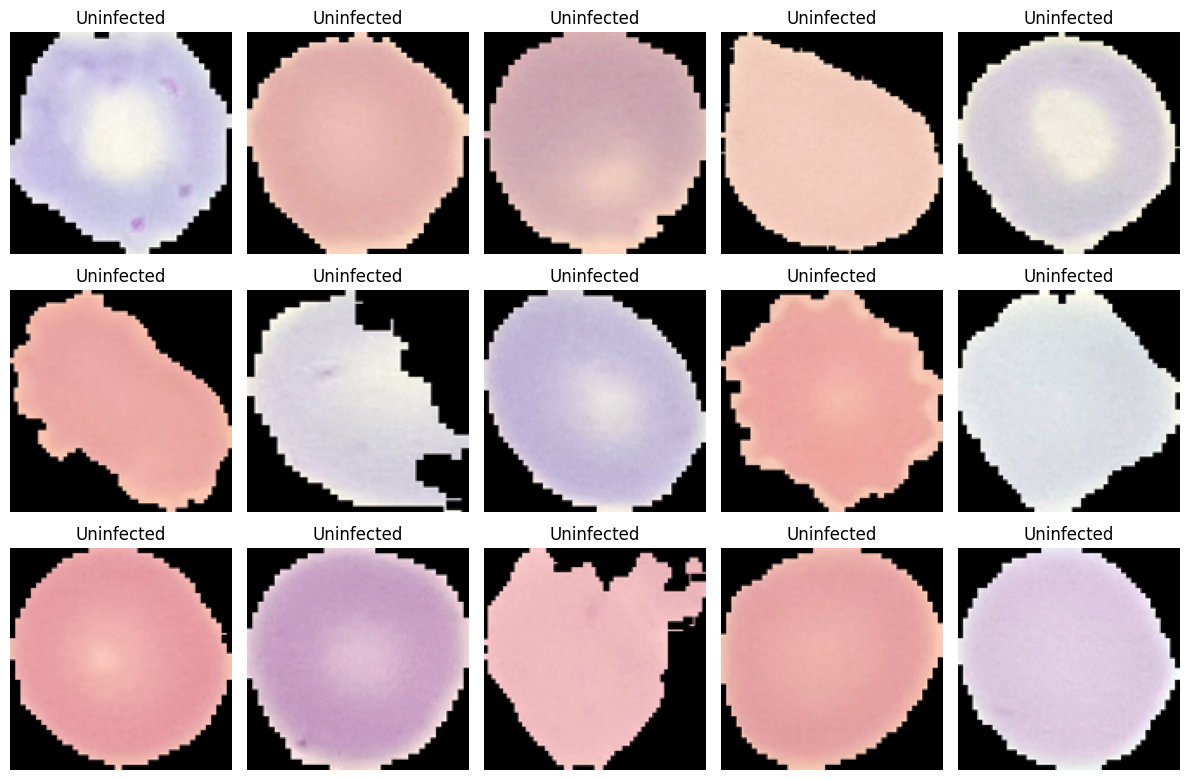

In [12]:
images_np = np.array(images)
labels_np = np.array(labels)
which_class = 1  # for example: 1 for 'Parasitized', 0 for 'Uninfected'
training_images_class = images_np[labels_np == which_class]
fig = plt.figure(figsize=(12, 8))
columns = 5
rows = 3

for i in range(1, columns * rows + 1):
    if i >= len(training_images_class):
        break  # Avoid indexing beyond available images
    img = training_images_class[i]
    fig.add_subplot(rows, columns, i)
    plt.title("Uninfected")
    plt.imshow(img.astype("uint8"))
    plt.axis('off')
plt.tight_layout()
plt.show()


## Baseline Model

Fundamentally, a baseline is a model that is both simple to set up and has a reasonable chance of providing decent results.

# To do:

1) Separate training and testing sets

2) Create a traditional neural network model for classification. Code examples are [here](https://colab.research.google.com/drive/1OGxD35fQxXdWNDwYGYpZcES5zgo6UvdO?authuser=1) for reference.

3) Plot your training and testing accuracy across epochs


## Challenge:

- Create another neural net with a different layer configuration. Does it improve performance?


In [22]:
from sklearn.model_selection import train_test_split

# Convert to numpy arrays
images_np = np.array(images)
labels_np = np.array(labels)

# Split the data
X_train, X_valid, y_train, y_valid = train_test_split(
    images_np, labels_np, random_state=0, test_size=0.2
)

# Normalize
X_train = X_train.astype('float32') / 255.0
X_valid = X_valid.astype('float32') / 255.0

import logging
logging.getLogger('tensorflow').disabled = True

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, BatchNormalization
from tensorflow.keras import regularizers

base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)


base_model.trainable = False


inputs = Input(shape=(128, 128, 3))


x = tf.keras.layers.RandomFlip("horizontal")(inputs)
x = tf.keras.layers.RandomRotation(0.1)(x)


x = base_model(x, training=False)


x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(2, activation='softmax')(x)


model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ],
    validation_data=(X_valid, y_valid),
    verbose=1
)

history


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 131ms/step - accuracy: 0.7102 - loss: 0.7370 - val_accuracy: 0.8676 - val_loss: 0.3341
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 0.8381 - loss: 0.4412 - val_accuracy: 0.9020 - val_loss: 0.2836
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.8526 - loss: 0.4006 - val_accuracy: 0.9100 - val_loss: 0.2659
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.8775 - loss: 0.3510 - val_accuracy: 0.9130 - val_loss: 0.2512
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.8794 - loss: 0.3414 - val_accuracy: 0.9160 - val_loss: 0.2464
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.8844 - loss: 0.3221 - val_accuracy: 0.9145 - val_loss: 0.2388
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.8842 - loss: 0.3174 - val_accuracy: 0.9190 - val_loss: 0.2315
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.8896 - loss: 0.3071 - val_accuracy: 0.

In [ ]:
from sklearn.model_selection import train_test_split

# Convert to numpy arrays
images_np = np.array(images)
labels_np = np.array(labels)

# Split the data
X_train, X_valid, y_train, y_valid = train_test_split(
    images_np, labels_np, random_state=0, test_size=0.2
)

# Normalize
X_train = X_train.astype('float32') / 255.0
X_valid = X_valid.astype('float32') / 255.0

import logging
logging.getLogger('tensorflow').disabled = True

from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras import regularizers

model = Sequential()
weight_decay = 0.0005

# regularizer.l2
# BatchNormalization
# Dropout

model.add(Conv2D(64, (3, 3), padding='same',
                    input_shape=(128,128,3),kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Conv2D(64, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Conv2D(128, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(256, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Conv2D(256, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Conv2D(256, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(512, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Conv2D(512, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Conv2D(512, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2, 2)))


model.add(Conv2D(512, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Conv2D(512, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Conv2D(512, (3, 3), padding='same',kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(512,kernel_regularizer=regularizers.l2(weight_decay)))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Dropout(0.5))
model.add(Dense(2))
model.add(Activation('softmax'))

# Build the model
model.compile(
    loss=tf.keras.losses.sparse_categorical_crossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

print(model.summary())

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=10,
    validation_data=(X_valid, y_valid),
    verbose=1
)

'''
history = model.fit(

      X_train, y_train,

      # number of samples to work through before updating the
      # internal model parameters via back propagation.
      batch_size=256,

      epochs=10,

      validation_split=0.2,

      verbose=1)
'''

In [16]:
from sklearn.model_selection import train_test_split
# X_train, X_valid, y_train, y_valid = train_test_split(images, labels, random_state = 0, test_size = 0.2)
'''
mnist = tf.keras.datasets.mnist
(training_images, training_labels), (testing_images, testing_labels) = mnist.load_data()
'''
# Split the data
X_train, X_valid, y_train, y_valid = train_test_split(
    images_np, labels_np, random_state=0, test_size=0.2
)

# Normalize
X_train = X_train.astype('float32') / 255.0

model = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(128, 128, 3)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(30, activation='relu'),
  tf.keras.layers.Dense(20, activation='relu'),
  tf.keras.layers.Dense(10, activation='relu'),
  tf.keras.layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy'])

history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
    ],
    validation_data=(X_valid, y_valid),
    verbose=1
)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.5040 - loss: 0.8944 - val_accuracy: 0.5097 - val_loss: 68.2486
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5849 - loss: 0.6692 - val_accuracy: 0.5492 - val_loss: 60.8171
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6036 - loss: 0.6546 - val_accuracy: 0.5762 - val_loss: 59.1413
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6243 - loss: 0.6399 - val_accuracy: 0.5932 - val_loss: 56.3585
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6409 - loss: 0.6274 - val_accuracy: 0.6077 - val_loss: 56.1246
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6556 - loss: 0.6159 - val_accuracy: 0.6142 - val_loss: 59.2878
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6675 - loss: 0.6052 - val_accuracy: 0.6277 - val_loss: 57.4895
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6754 - loss: 0.5973 - val_accuracy: 0.6

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


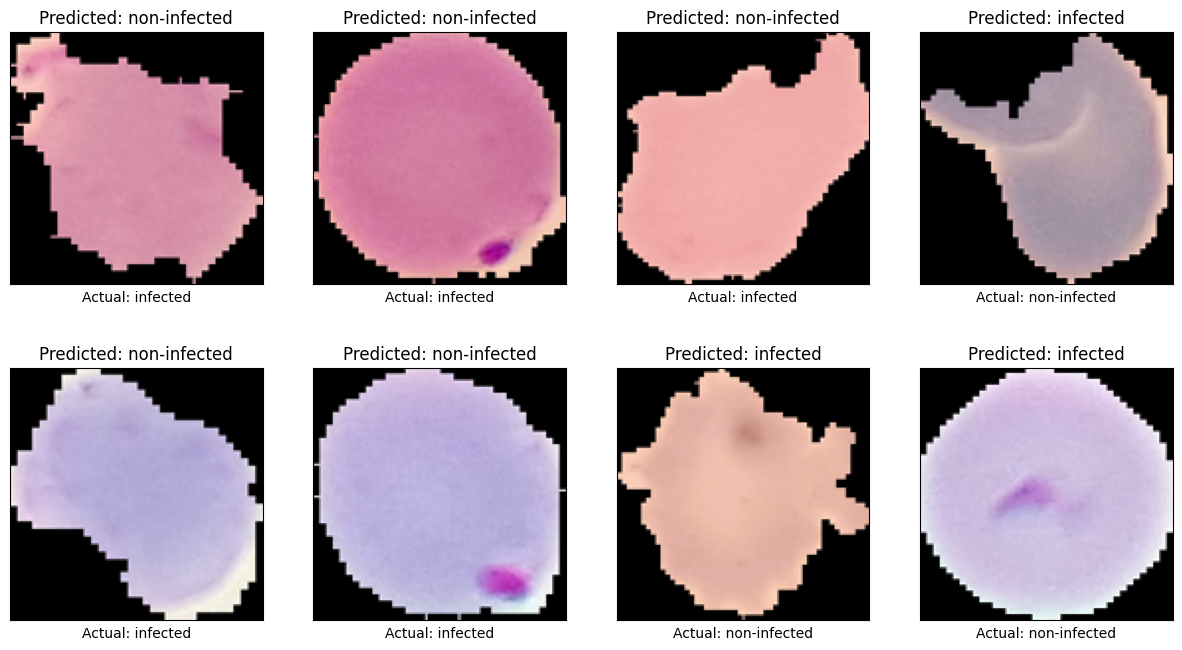

In [23]:
predicted_classes = model.predict(X_valid)
predicted_classes = np.argmax(predicted_classes, axis=1)
incorrect = np.nonzero(predicted_classes!=y_valid)[0]
class_names = ['infected', 'non-infected']

# Display the first 16 incorrectly classified images from the test data set
plt.figure(figsize=(15, 8))
for j, incorrect in enumerate(incorrect[0:8]):
    plt.subplot(2, 4, j+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_valid[incorrect].reshape(128, 128, 3), cmap="Reds")
    plt.title("Predicted: {}".format(class_names[predicted_classes[incorrect]]))
    plt.xlabel("Actual: {}".format(class_names[y_valid[incorrect]]))

63/63 - 2s - 25ms/step - accuracy: 0.9265 - loss: 0.2050


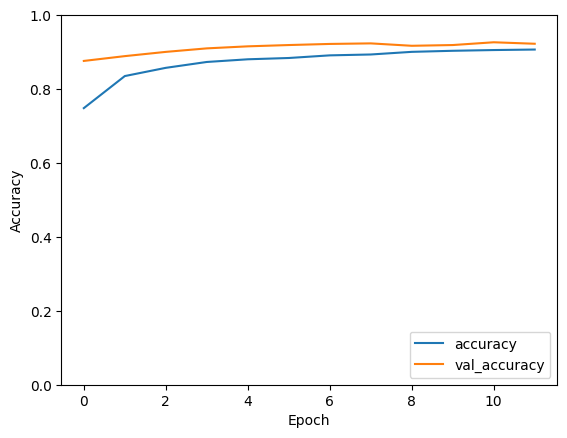

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1]) # recall accuracy is between 0 to 1
plt.legend(loc='lower right') # specify location of the legend

test_loss, test_acc = model.evaluate(X_valid, y_valid, verbose=2)

## Advanced Model

Examples:
- Build a model that is more complex or can improve upon your predictions for classification.

## Model Tuning

Recall in Week 5, we discussed hyperparameters tuning. You can refer to this code [here](https://colab.research.google.com/drive/1BdW6zSQ2XAUcLI83CANcFBQaBw5WgepK).

## Performance Summary

Make a presentation of your result. You can refer to the syntax below.

Markdown | Preview
--- | ---
`**Model 1**` | **Model 2**
`*70%*` or `_italicized text_` | *90%*
`` `Monospace` `` | `Monospace`
`~~strikethrough~~` | ~~strikethrough~~
`[A link](https://www.google.com)` | [A link](https://www.google.com)
`![An image](https://www.google.com/images/rss.png)` | ![An image](https://www.google.com/images/rss.png)

More resources about creating tables in markdown of colab can be found [here](https://colab.research.google.com/notebooks/markdown_guide.ipynb#scrollTo=Lhfnlq1Surtk).

## Interpretation and Future Work

Present and also interpret your experimental performance. Comment on potential future work or research questions that your project leads to.